In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
GREEN = (0, 255, 0)
RED = (255, 0, 0)

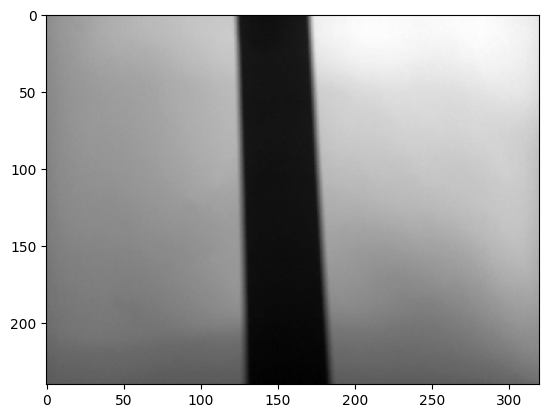

In [21]:
image = cv2.imread('line_1.jpg')
resized = cv2.resize(image, (320, 240))
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')


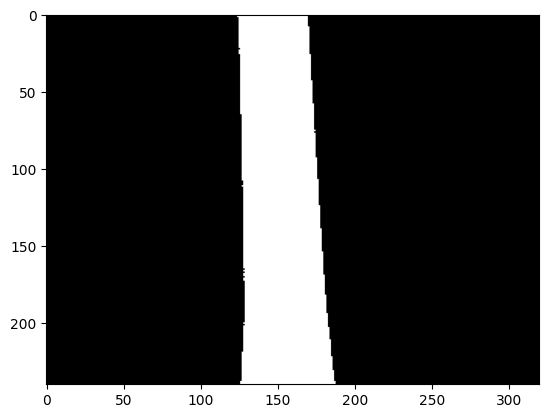

In [22]:
masked = cv2.inRange(gray, 0, 50)
plt.imshow(masked, cmap='gray')

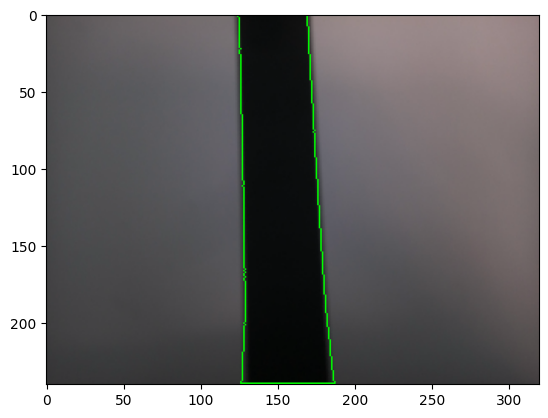

In [23]:
contours, _ = cv2.findContours(masked, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)
cv2.drawContours(resized, [largest_contour], -1, GREEN, 1)
plt.imshow(resized)

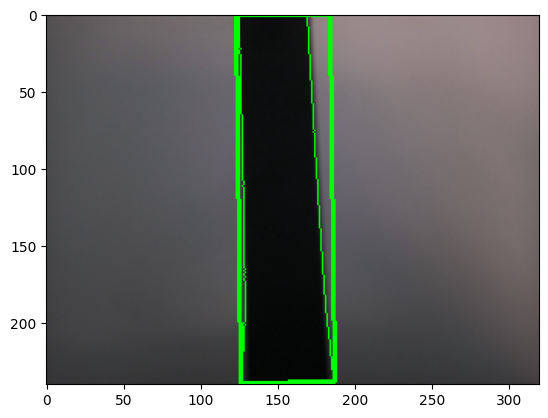

In [18]:
rect = cv2.minAreaRect(largest_contour)
box = cv2.boxPoints(rect)
box = np.intp(box)
cv2.drawContours(resized, [box], 0, GREEN, 2)
plt.imshow(resized)

In [19]:
((center_x, center_y)), (width, height), theta = rect

if width < height:
    theta += 90.0
    length = height
else:
    length = width

theta = theta + 180
int(theta), int(length)

(269, 239)

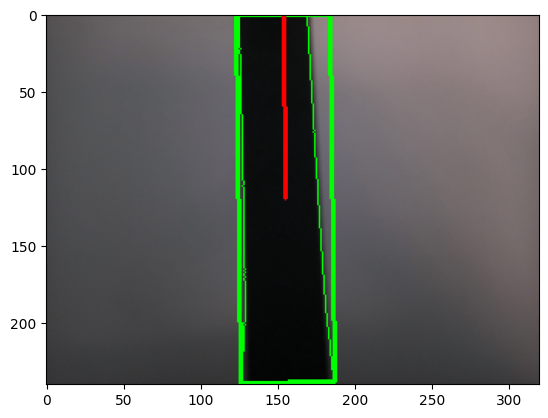

In [20]:
theta = np.deg2rad(theta)
end = (
    int(center_x + length/2 * np.cos(theta)), 
    int(center_y + length/2 * np.sin(theta))
)
cv2.line(resized, (int(center_x), int(center_y)), end, RED, 2)
plt.imshow(resized)

In [ ]:
# The output is a vector for the line direction, and an intersection point
[vec_x,vec_y,intersects_x,intersects_y] = cv2.fitLine(largest_contour, cv2.DIST_L2,0,0.01,0.01)
# We want to extend the line from the intersection point until it hits the image borders
right_boundary_length = (320 - intersects_x) / vec_x if vec_x != 0 else 1
bottom_boundary_length = (240 - intersects_y) / vec_y if vec_y != 0 else 1
left_boundary_length = (intersects_x) / vec_x if vec_x != 0 else 1
top_boundary_length = (intersects_y) / vec_y if vec_y != 0 else 1


That got complicated quickly... Not sure it's "better" than the min area rectangle approach.

In [64]:
image = cv2.imread('line_1.jpg')

def theta_and_cx_from_image(image):
    resized = cv2.resize(image, (320, 240))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    masked = cv2.inRange(gray, 0, 50)
    # masked = cv2.inRange(gray, 0, 50)
    contours, _ = cv2.findContours(masked, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, None
    largest_contour = max(contours, key=cv2.contourArea)
    cv2.drawContours(resized, [largest_contour], -1, GREEN, 1)
    # Find a minimum bounding rect
    rect = cv2.minAreaRect(largest_contour) 
    ((cx, cy)), (w, h), theta = rect

    # Angle of the longest side (convert so it points along the longer edge)
    if w < h:
        theta += 90.0
        length = h
    else:
        length = w
    # theta is usually pointing down. We need to invert it.
    theta = theta + 180

    theta = np.deg2rad(theta)
    # draw the rect in GREEN
    box = cv2.boxPoints(rect)
    box = np.intp(box)
    cv2.drawContours(resized, [box], 0, GREEN, 2)

    # draw a line through the center
    # with orientation theta
    # pt1 = (int(cx - length * np.cos(theta)), int(cy - length * np.sin(theta)))
    pt2 = (int(cx + length * np.cos(theta)), int(cy + length * np.sin(theta)))
    cv2.line(resized, (int(cx), int(cy)), pt2, RED, 2)

    return cx, theta, resized

Theta is 4.703985908197163


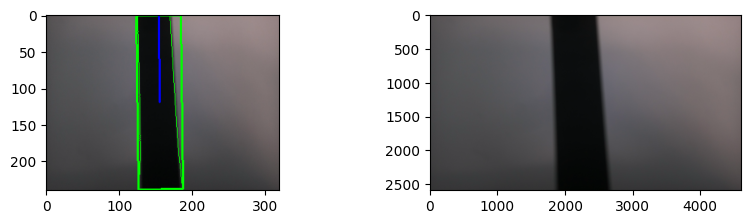

In [27]:
def process_and_plot(filename):
    image = cv2.imread(filename)

    cx, theta, processed_image = theta_and_cx_from_image(image)
    print("Theta is", theta)

    plt.figure(figsize=(10, 5))
    plt.subplot(2, 2, 1)
    plt.imshow(processed_image)
    plt.subplot(2, 2, 2)
    plt.imshow(image, cmap="gray")
process_and_plot("line_1.jpg")

Theta is 4.9364126265435555


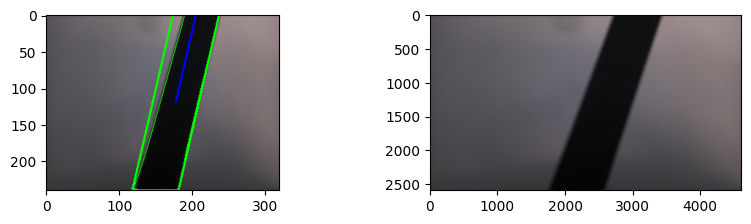

In [65]:
process_and_plot("line_2.jpg")

Theta is 5.695182774307684


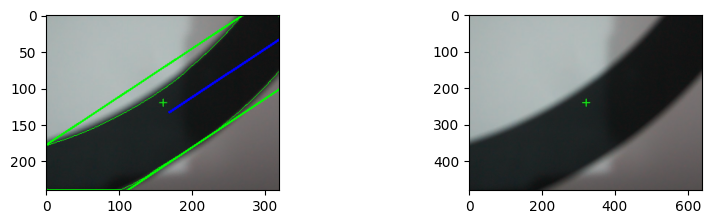

In [66]:
process_and_plot("line-it-missed.jpg")

Theta is 6.283185307179586


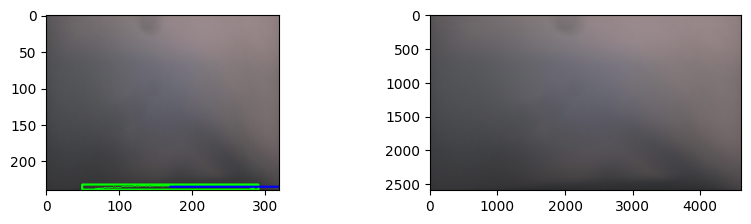

In [67]:
process_and_plot("empty_gray.jpg")

Needs work there - I guess this contour is junk, and we might want to filter it out based on size or shape.

Theta is 3.60213469879385


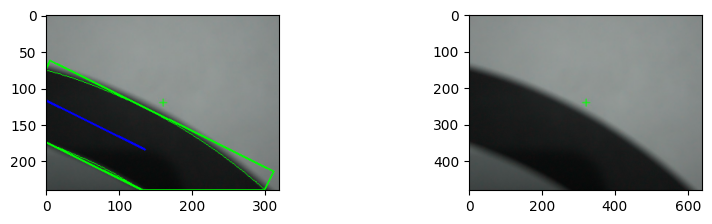

In [39]:
process_and_plot("lines-missed.jpg")

Theta is 4.995198212471043


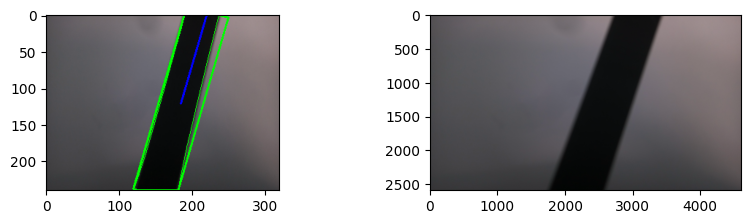

In [40]:
process_and_plot("line_2.jpg")


Theta is 5.122822251519334


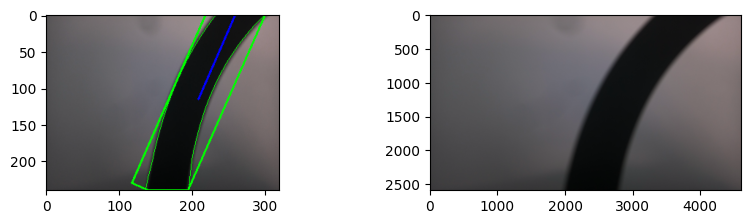

In [41]:
process_and_plot("line_3.jpg")


Theta is 4.024858990991427


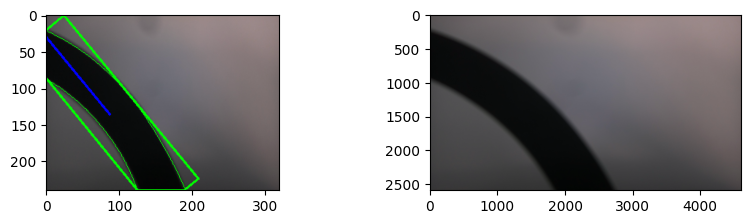

In [42]:
process_and_plot("line_4.jpg")


Theta is 4.508510549975619


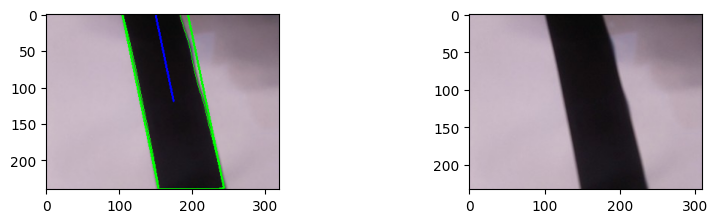

In [43]:
process_and_plot("line-6.jpg")

Theta is 4.71238898038469


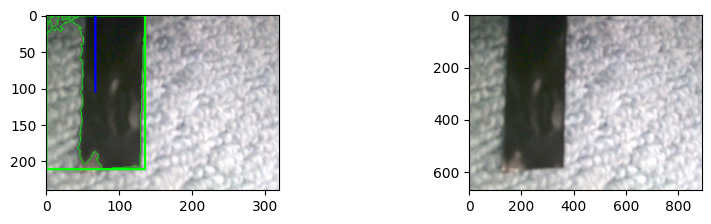

In [44]:
process_and_plot("carpet_line1.jpg")